# KNN

In [27]:
from datetime import datetime
from nltk.tokenize import sent_tokenize
from nltk.tokenize import word_tokenize
from scipy.sparse import load_npz, hstack
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    RocCurveDisplay
)
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import nltk
import numpy as np
import optuna
import pandas as pd

Se carga dataset.

In [28]:
X_train = load_npz('datasets/X_train.npz')
X_test = load_npz('datasets/X_test.npz')
X_extra_train = pd.read_csv('datasets/X_extra_train.csv')
X_extra_test = pd.read_csv('datasets/X_extra_test.csv')

y_train = pd.read_csv('datasets/y_train.csv')['label']
y_test = pd.read_csv('datasets/y_test.csv')['label']

Se codifican y estandarizan variables ya que KNN requiere valores numéricos estandarziados.

In [29]:
ohe = OneHotEncoder(drop='first', handle_unknown='ignore')
scaler = StandardScaler(with_mean=False)

extra_features_preprocessor = ColumnTransformer(transformers=[
    ('bin', 'passthrough', ['has_link']),
    ('cat', ohe, ['words_count_cat']),
    ('num', scaler, ['clause_density', 'pronoun_density']),
], remainder='passthrough')

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_extra_proc = pd.DataFrame(
    extra_features_preprocessor.fit_transform(X_extra_train),
    columns=extra_features_preprocessor.get_feature_names_out()
)
X_test_extra_proc = pd.DataFrame(
    extra_features_preprocessor.transform(X_extra_test),
    columns=extra_features_preprocessor.get_feature_names_out()
)

X_train = hstack([X_train_scaled, X_extra_train.drop(['Email Text Raw'], axis=1, inplace=True)])
X_test = hstack([X_test_scaled, X_extra_test.drop(['Email Text Raw'], axis=1, inplace=True)])

Se inicializa KNN con _k = 5_ y se prueba.

In [30]:
knn_model = KNeighborsClassifier(n_neighbors=5)

start_train_time = datetime.now()
knn_model.fit(X_train_scaled, y_train)
end_train_time = datetime.now()

train_duration = end_train_time - start_train_time

start_predict_duration = datetime.now()
y_pred = knn_model.predict(X_test_scaled)
end_predict_duration = datetime.now()

predict_duration = end_predict_duration - start_predict_duration

#### Métricas

Se evalúa.

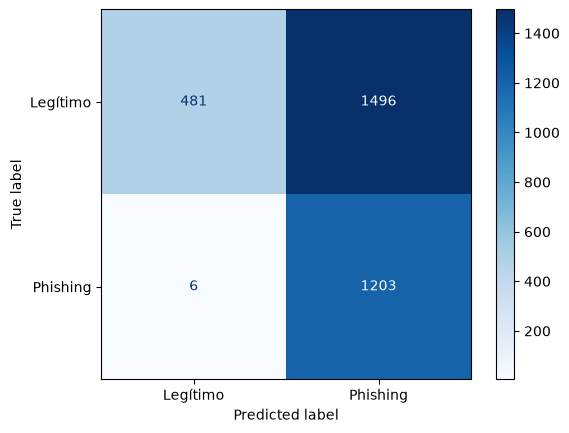

In [31]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Legítimo', 'Phishing'], cmap='Blues')

In [32]:
cm_knn = confusion_matrix(y_test, y_pred)
P = cm_knn[1, :].sum()
N = cm_knn[0, :].sum()
TP = cm_knn[1, 1]
TN = cm_knn[0, 0]

TPR_knn = TP / P
TNR_knn = TN / N
balanced_accuracy_knn = (TPR_knn + TNR_knn) / 2

precision_knn = precision_score(y_test, y_pred, zero_division=0)
recall_knn = recall_score(y_test, y_pred, zero_division=0)
f1_knn = f1_score(y_test, y_pred, zero_division=0)

print(f"Exactitud balanceada:    {balanced_accuracy_knn:.4f}")
print(f"Precisión:               {precision_knn:.4f}")
print(f"Sensibilidad (Recall):   {TPR_knn:.4f}")
print(f"F1-score:                {f1_knn:.4f}")
print(f"Especificidad:           {TNR_knn:.4f}")
print(f"Recuperación (Recall):   {recall_knn:.4f}")
print(f"Tiempo de entrenamiento: {train_duration}")
print(f"Tiempo de predicción:    {predict_duration}")

Exactitud balanceada:    0.6192
Precisión:               0.4457
Sensibilidad (Recall):   0.9950
F1-score:                0.6157
Especificidad:           0.2433
Recuperación (Recall):   0.9950
Tiempo de entrenamiento: 0:00:00.003411
Tiempo de predicción:    0:00:01.557063


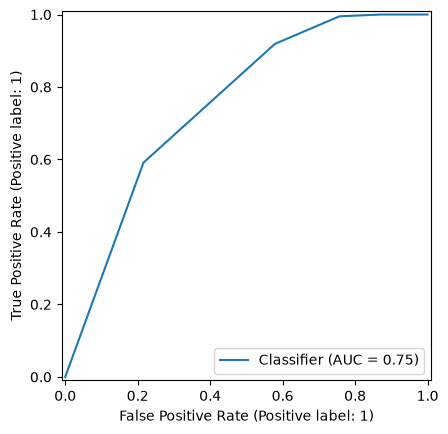

In [33]:
y_scores = knn_model.predict_proba(X_test)[:, 1]

RocCurveDisplay.from_predictions(y_test, y_scores)

Puede ser mejor.

## Optimización de parámetros

Se define la función objetivo y se prepara el estudio.

In [34]:
def objective(trial):
    n_neighbors = trial.suggest_int("n_neighbors", 1, 50)
    weights = trial.suggest_categorical("weights", ["uniform", "distance"])
    metric = trial.suggest_categorical("metric", ["euclidean", "manhattan", "cosine"])

    model = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, metric=metric)

    score = cross_val_score(model, X_train_scaled, y_train, cv=3, scoring='f1', n_jobs=-1)
    return score.mean()

def champion_callback(study, frozen_trial):
    winner = study.user_attrs.get("winner", None)

    if study.best_value and winner != study.best_value:
        study.set_user_attr("winner", study.best_value)
        if winner:
            improvement_percent = (abs(winner - study.best_value) / study.best_value)
            improvement_percent *= 100
            print(
                f"Trial {frozen_trial.number} achieved value: {frozen_trial.value} "
                f"with {improvement_percent: .4f}% improvement"
            )
        else:
            print(f"Initial trial {frozen_trial.number} achieved value: " 
            f"{frozen_trial.value}")

optuna.logging.set_verbosity(optuna.logging.ERROR)

Se ejecutan 100 trials.

In [35]:
study = optuna.create_study(direction="maximize", pruner=optuna.pruners.HyperbandPruner)
start_train_time_opt = datetime.now()
study.optimize(objective, n_trials=100, callbacks=[champion_callback], n_jobs=-1)
end_train_time_opt = datetime.now()

train_duration_opt = end_train_time_opt - start_train_time_opt

Initial trial 6 achieved value: 0.5814455312421444
Trial 7 achieved value: 0.9158432570988758 with  36.5125% improvement
Trial 15 achieved value: 0.9162571384872122 with  0.0452% improvement
Trial 17 achieved value: 0.9167829255250606 with  0.0574% improvement
Trial 18 achieved value: 0.9168746255913011 with  0.0100% improvement


In [36]:
best_params = study.best_params
best_params

{'n_neighbors': 48, 'weights': 'distance', 'metric': 'cosine'}

Se entrena el modelo con los parámetros resultantes de la optimización.

In [37]:
optimized_knn_model = KNeighborsClassifier(**best_params)

start_train_time_opt = datetime.now()
optimized_knn_model.fit(X_train_scaled, y_train)
end_train_time_opt = datetime.now()

train_duration_opt = train_duration_opt + (end_train_time_opt - start_train_time_opt)

start_predict_duration_opt = datetime.now()
y_pred = optimized_knn_model.predict(X_test_scaled)
end_predict_duration_opt = datetime.now()

predict_duration_opt = end_predict_duration_opt - start_predict_duration_opt

#### Métricas

Se evalúa.

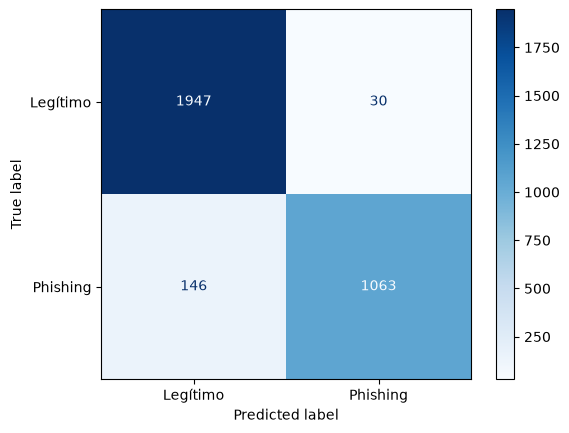

In [38]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Legítimo', 'Phishing'], cmap='Blues')

In [39]:
cm_optimized_knn = confusion_matrix(y_test, y_pred)
P_opt = cm_optimized_knn[1, :].sum()
N_opt = cm_optimized_knn[0, :].sum()
TP_opt = cm_optimized_knn[1, 1]
TN_opt = cm_optimized_knn[0, 0]

TPR_knn_opt = TP_opt / P_opt
TNR_knn_opt = TN_opt / N_opt
balanced_accuracy_knn_opt = (TPR_knn_opt + TNR_knn_opt) / 2

precision_knn_opt = precision_score(y_test, y_pred, zero_division=0)
recall_knn_opt = recall_score(y_test, y_pred, zero_division=0)
f1_knn_opt = f1_score(y_test, y_pred, zero_division=0)

print("                         Antes           Después")
print(f"Exactitud balanceada:    {balanced_accuracy_knn:.4f}          {balanced_accuracy_knn_opt:.4f}")
print(f"Precisión:               {precision_knn:.4f}          {precision_knn_opt:.4f}")
print(f"Sensibilidad (Recall):   {TPR_knn:.4f}          {TPR_knn_opt:.4f}")
print(f"F1-score:                {f1_knn:.4f}          {f1_knn_opt:.4f}")
print(f"Especificidad:           {TNR_knn:.4f}          {TNR_knn_opt:.4f}")
print(f"Recuperación (Recall):   {recall_knn:.4f}          {recall_knn_opt:.4f}")
print(f"Tiempo de entrenamiento: {train_duration}  {train_duration_opt}")
print(f"Tiempo de predicción:    {predict_duration}  {predict_duration_opt}")

                         Antes           Después
Exactitud balanceada:    0.6192          0.9320
Precisión:               0.4457          0.9726
Sensibilidad (Recall):   0.9950          0.8792
F1-score:                0.6157          0.9235
Especificidad:           0.2433          0.9848
Recuperación (Recall):   0.9950          0.8792
Tiempo de entrenamiento: 0:00:00.003411  0:03:17.599876
Tiempo de predicción:    0:00:01.557063  0:00:01.574461


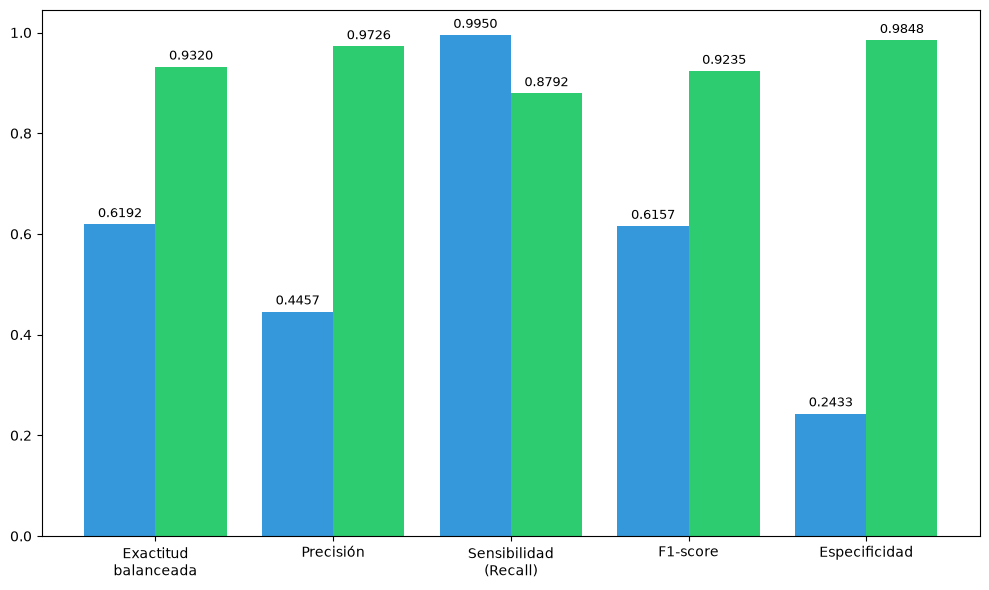

In [40]:
metrics_names = [
    'Exactitud\nbalanceada', 
    'Precisión', 
    'Sensibilidad\n(Recall)', 
    'F1-score', 
    'Especificidad'
]

before_vals = [
    balanced_accuracy_knn, 
    precision_knn, 
    TPR_knn, 
    f1_knn, 
    TNR_knn
]

after_vals = [
    balanced_accuracy_knn_opt, 
    precision_knn_opt, 
    TPR_knn_opt, 
    f1_knn_opt, 
    TNR_knn_opt
]

x = np.arange(5)

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - 0.2, before_vals, 0.4, color='#3498db')
for rect in rects1:
    height = rect.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)
rects2 = ax.bar(x + 0.2, after_vals, 0.4, color='#2ecc71')
for rect in rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=10)

plt.tight_layout()
plt.show()


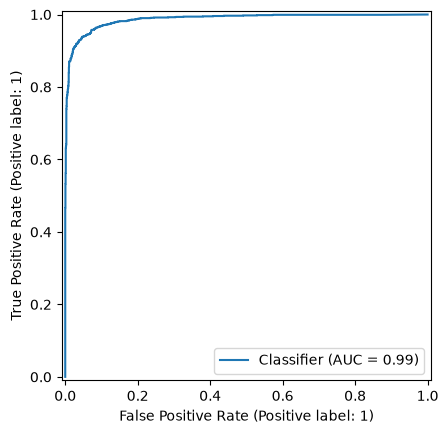

In [41]:
y_scores = optimized_knn_model.predict_proba(X_test)[:, 1]

RocCurveDisplay.from_predictions(y_test, y_scores)

Funcionó.